# Enfriamiento térmico de la corteza de una estrella de neutrones


$$
\frac{\partial T}{\partial t}
=
\alpha \frac{\partial^2 T}{\partial z^2}
-
\epsilon_\nu T^5
$$

dadas las siguientes condiciones de frontera e iniciales.

$$T(0,t)=T_{\text{surf}}=10^6\,K$$
$$T(L,t)=T_{\text{core}}=10^9\,K$$
$$T(z,0)=T_{\text{core}}$$

con
$$
L = 10^3\,m
\qquad
\alpha = 10^{-2}\,\frac{m^2}{s}
\qquad
T_{\text{core}} = 10^9\,K
$$

$$
T_{\text{surf}} = 10^6\,K
\qquad
\epsilon_\nu = 10^{-53}\,\frac{1}{K^8 s}
\qquad
t_{\max}=10^6\,s
$$

usando el método explícito, implícito y Crank--Nicolson.

## Métodos: 

### Método Explícito

Para discretizar la ecuación de enfriamiento utilizamos un esquema explícito en tiempo y diferencias centrales en el espacio:

$$
T_i^{\,n+1}
=
T_i^{\,n}
+
\lambda
\left(
T_{i+1}^{\,n}
-
2T_i^{\,n}
+
T_{i-1}^{\,n}
\right)
-
\Delta t\,\epsilon_\nu \left(T_i^{\,n}\right)^5
$$

donde el parámetro adimensional está dado por

$$
\lambda
=
\frac{\alpha\,\Delta t}{(\Delta z)^2}
$$

El término proporcional a \(\epsilon_\nu\) representa las pérdidas de energía debidas a emisión de neutrinos.

Para garantizar estabilidad numérica, el método requiere cumplir la condición

$$
\lambda < \frac{1}{2}
$$

por lo que el paso temporal \(\Delta t\) no puede elegirse arbitrariamente grande.

### Método Implícito

El esquema implícito para la ecuación de difusión es:

$$
T_i^{n+1}
=
T_i^n
+
\lambda
\left(
T_{i+1}^{n+1}
-
2T_i^{n+1}
+
T_{i-1}^{n+1}
\right)
-
\Delta t\,\epsilon_\nu (T_i^{n+1})^5
$$

con

$$
\lambda
=
\frac{\alpha \Delta t}{\Delta z^2}
$$

Reordenando términos:

$$
-\lambda T_{i-1}^{n+1}
+
(1+2\lambda)T_i^{n+1}
-
\lambda T_{i+1}^{n+1}
=
T_i^n
-
\Delta t\,\epsilon_\nu (T_i^{n+1})^5
$$

Este método es incondicionalmente estable.

### Método de Crank--Nicolson

El esquema de Crank--Nicolson combina el método explícito e implícito tomando el promedio temporal entre los niveles \(n\) y \(n+1\). De esta forma, la discretización queda

$$
-\frac{\lambda}{2}T_{i-1}^{\,n+1}
+
(1+\lambda)T_i^{\,n+1}
-
\frac{\lambda}{2}T_{i+1}^{\,n+1}
=
\frac{\lambda}{2}T_{i-1}^{\,n}
+
(1-\lambda)T_i^{\,n}
+
\frac{\lambda}{2}T_{i+1}^{\,n}
$$

donde

$$
\lambda
=
\frac{\alpha\,\Delta t}{(\Delta z)^2}
$$

Este método posee precisión de segundo orden tanto en tiempo como en espacio:

$$
\mathcal{O}(\Delta z^2) + \mathcal{O}(\Delta t^2)
$$

Además, el esquema es incondicionalmente estable, lo que permite utilizar pasos temporales más grandes en comparación con el método explícito.



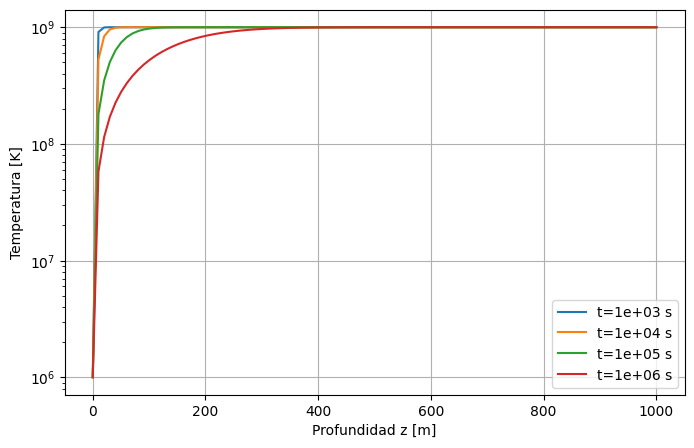

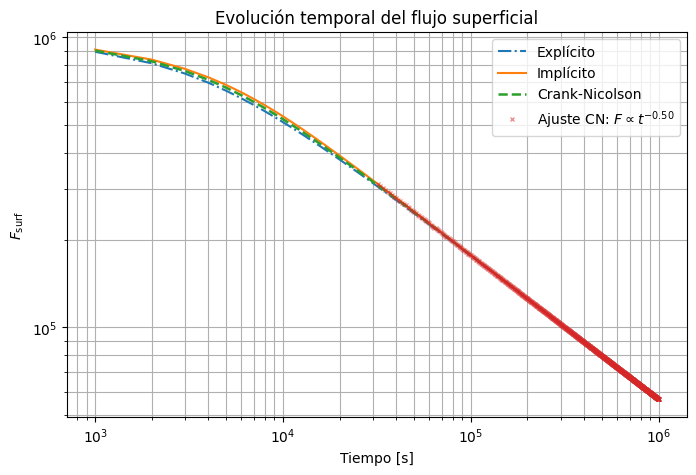

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETROS FISICOS
L = 1.0e3
alpha = 1.0e-2
eps_nu = 1.0e-53
T_core = 1.0e9
T_surf = 1.0e6

t_max = 1.0e6
N = 100

dx = L/(N-1)

# ALGORITMO DE THOMAS

def thomas(a,b,c,d):

    n = len(d)

    cp = np.zeros(n-1)
    dp = np.zeros(n)
    x = np.zeros(n)

    cp[0] = c[0]/b[0]
    dp[0] = d[0]/b[0]

    for i in range(1,n-1):
        m = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i]/m
        dp[i] = (d[i] - a[i-1]*dp[i-1])/m

    m = b[n-1] - a[n-2]*cp[n-2]
    dp[n-1] = (d[n-1] - a[n-2]*dp[n-2])/m

    x[n-1] = dp[n-1]

    for i in range(n-2,-1,-1):
        x[i] = dp[i] - cp[i]*x[i+1]

    return x

# METODO EXPLICITO

def metodo_explicito(dt):

    lam = alpha*dt/dx**2
    n_steps = int(t_max/dt)

    T = np.ones(N)*T_core
    T[0] = T_surf

    tiempos_guardar = [1e3,1e4,1e5,1e6]

    historial = []
    flujo = []
    tiempos = []

    t = 0

    for step in range(n_steps):

        T_new = T.copy()

        for i in range(1,N-1):

            Qnu = eps_nu*T[i]**5

            T_new[i] = (
                T[i]
                + lam*(T[i+1]-2*T[i]+T[i-1])
                - dt*Qnu
            )

        T_new[0] = T_surf
        T_new[-1] = T_core

        T = T_new

        t += dt

        Fsurf = -alpha*(T[1]-T[0])/dx

        flujo.append(abs(Fsurf))
        tiempos.append(t)

        if np.isclose(t, tiempos_guardar).any():
            historial.append((t,T.copy()))

    return historial, tiempos, flujo


# METODO IMPLICITO

def metodo_implicito(dt):

    lam = alpha*dt/dx**2
    n_steps = int(t_max/dt)

    T = np.ones(N)*T_core
    T[0] = T_surf

    tiempos_guardar = [1e3,1e4,1e5,1e6]

    historial = []
    flujo = []
    tiempos = []

    nint = N-2

    a = -lam*np.ones(nint-1)
    b = (1+2*lam)*np.ones(nint)
    c = -lam*np.ones(nint-1)

    t = 0

    for step in range(n_steps):

        rhs = np.zeros(nint)

        for i in range(1,N-1):

            Qnu = eps_nu*T[i]**5

            rhs[i-1] = T[i] - dt*Qnu

        rhs[0] += lam*T_surf
        rhs[-1] += lam*T_core

        Tint = thomas(a,b,c,rhs)

        T[1:-1] = Tint

        T[0] = T_surf
        T[-1] = T_core

        t += dt

        Fsurf = -alpha*(T[1]-T[0])/dx

        flujo.append(abs(Fsurf))
        tiempos.append(t)

        if np.isclose(t, tiempos_guardar).any():
            historial.append((t,T.copy()))

    return historial, tiempos, flujo

# CRANK NICOLSON

def crank_nicolson(dt):

    lam = alpha*dt/dx**2
    n_steps = int(t_max/dt)

    T = np.ones(N)*T_core
    T[0] = T_surf

    tiempos_guardar = [1e3,1e4,1e5,1e6]

    historial = []
    flujo = []
    tiempos = []

    nint = N-2

    a = -(lam/2)*np.ones(nint-1)
    b = (1+lam)*np.ones(nint)
    c = -(lam/2)*np.ones(nint-1)

    t = 0

    for step in range(n_steps):

        rhs = np.zeros(nint)

        for i in range(1,N-1):

            Qnu = eps_nu*T[i]**5

            rhs[i-1] = (
                (lam/2)*T[i-1]
                + (1-lam)*T[i]
                + (lam/2)*T[i+1]
                - dt*Qnu
            )

        rhs[0] += (lam/2)*T_surf
        rhs[-1] += (lam/2)*T_core

        Tint = thomas(a,b,c,rhs)

        T[1:-1] = Tint

        T[0] = T_surf
        T[-1] = T_core

        t += dt

        Fsurf = -alpha*(T[1]-T[0])/dx

        flujo.append(abs(Fsurf))
        tiempos.append(t)

        if np.isclose(t, tiempos_guardar).any():
            historial.append((t,T.copy()))

    return historial, tiempos, flujo

# EJECUCION

hist_CN, t_CN, F_CN = crank_nicolson(1e3)

x = np.linspace(0,L,N)

plt.figure(figsize=(8,5))

for t, T in hist_CN:
    plt.plot(x,T,label=f't={t:.0e} s')

plt.xlabel('Profundidad z [m]')
plt.ylabel('Temperatura [K]')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

# CORRECCIÓN PARA AGREGAR LOS 3 MÉTODOS Y NO SOLO UNO 
# EJECUCION DE LOS 3 METODOS

dt_exp = 1e3
dt_imp = 1e3
dt_cn  = 1e3

hist_exp, t_exp, F_exp = metodo_explicito(dt_exp)

hist_imp, t_imp, F_imp = metodo_implicito(dt_imp)

hist_CN, t_CN, F_CN = crank_nicolson(dt_cn)

# REGRESION PARA CRANK-NICOLSON

t_CN = np.array(t_CN)
F_CN = np.array(F_CN)

mask_cn = t_CN > 10**4.5

log_t_cn = np.log10(t_CN[mask_cn])
log_F_cn = np.log10(F_CN[mask_cn])

pendiente_cn, intercepto_cn = np.polyfit(
    log_t_cn,
    log_F_cn,
    1
)

exponente_cn = -pendiente_cn

F_fit_cn = (
    10**intercepto_cn
    * t_CN[mask_cn]**pendiente_cn
)


# GRAFICA DE FLUJO SUPERFICIAL

plt.figure(figsize=(8,5))

plt.loglog(
    t_exp,
    F_exp,
    label='Explícito',
    linestyle='-.',
    linewidth=1.5
)

plt.loglog(
    t_imp,
    F_imp,
    label='Implícito',
    linestyle='-',
    linewidth=1.5
)

plt.loglog(
    t_CN,
    F_CN,
    label='Crank-Nicolson',
    linestyle='--',
    linewidth=1.8
)

plt.loglog(
    t_CN[mask_cn],
    F_fit_cn,
    marker='x',
    linestyle='None',
    markersize=3,
    alpha=0.5,
    label=fr'Ajuste CN: $F \propto t^{{-{exponente_cn:.2f}}}$'
)

plt.xlabel('Tiempo [s]')
plt.ylabel(r'$F_{\mathrm{surf}}$')
plt.title('Evolución temporal del flujo superficial')
plt.grid(True, which='both')
plt.legend()
plt.show()

## Comportamiento asintótico del flujo

Para tiempos grandes, el flujo superficial presenta un comportamiento tipo ley de potencia. Suponemos entonces una dependencia de la forma

$$F_{\mathrm{surf}}(t) \propto t^{-\beta}$$

o equivalentemente

$$F_{\mathrm{surf}}(t) = A, t^{-\beta}$$

donde $(A)$ es una constante y $(\beta)$ corresponde al exponente de decaimiento.

Tomando logaritmo en ambos lados se obtiene una relación lineal:

$$
\log(F_{\mathrm{surf}})
=
\log(A)
-
\beta \log(t)
$$

## Comparación entre los métodos numéricos

Se compararon los métodos Explícito, Implícito y Crank--Nicolson utilizando
$(\Delta t = 10^3,\mathrm{s})$ y $(\Delta t = 10^4\,\mathrm{s})$.

Para $(\Delta t = 10^3,\mathrm{s})$, los tres métodos producen resultados físicamente consistentes y perfiles de temperatura similares. El flujo superficial obtenido presenta el mismo comportamiento global en todos los casos, aunque existen pequeñas diferencias numéricas asociadas al orden de precisión de cada esquema.

El método explícito reproduce adecuadamente la evolución térmica únicamente cuando se satisface la condición de estabilidad

$$
\lambda
=
\frac{\alpha \Delta t}{(\Delta z)^2}
\leq \frac{1}{2}.
$$

Al aumentar el paso temporal a $$(\Delta t = 10^4,\mathrm{s})$$, el esquema explícito comienza a presentar inestabilidades numéricas, reflejadas en oscilaciones y divergencias no físicas en la solución.

Por otro lado, los métodos Implícito y Crank--Nicolson permanecen estables incluso para pasos temporales grandes, debido a que son esquemas incondicionalmente estables. Sin embargo, el método implícito introduce una mayor difusión numérica, suavizando el perfil térmico con respecto a los otros métodos.

El método de Crank--Nicolson ofrece el mejor balance entre estabilidad y precisión, ya que conserva estabilidad para valores grandes de $$(\Delta t)$$ y además posee error de segundo orden tanto en tiempo como en espacio:

$$\mathcal{O}(\Delta t^2) + \mathcal{O}(\Delta z^2).$$

En consecuencia, Crank--Nicolson resulta ser el método más adecuado para describir la evolución temporal del enfriamiento térmico de la corteza de la estrella de neutrones.